# **Statistical Testing**

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from IPython.display import display, Markdown

from scipy.stats import jarque_bera

from statsmodels.tsa.stattools import (
    adfuller,
    kpss,
    acf,
    pacf,
)

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
)

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf,
)

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
)

from statsmodels.tools.tools import add_constant

In [2]:
DATA_PATH = Path("../data/processed/processed_data.csv")
OUTPUT_DIR = Path("../outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATE_COL = "Date"
TARGET_COL = "fx_return"

LEVEL_COLS = [
    "usd_vnd",
    "vix",
    "us_10y",
    "dxy",
    "vnindex",
    "wti_oil",
]

SHOCK_COLS = [
    "vix_change",
    "us10y_change",
    "dxy_return",
    "oil_change",
    "vnindex_return",
]

TRANSFORMED_COLS = [TARGET_COL] + SHOCK_COLS
VIF_COLS = SHOCK_COLS + ["crisis_dummy"]

LB_LAGS = [5, 10, 20]
ARCH_LAGS = 10

print("Input file :", DATA_PATH)
print("Table dir  :", TABLE_DIR.resolve())
print("Figure dir :", FIGURE_DIR.resolve())

Input file : ../data/processed/processed_data.csv
Table dir  : /Users/klinhfhm/Documents/Seminar 6/Time Series/finalll/final-timeseries/outputs/tables
Figure dir : /Users/klinhfhm/Documents/Seminar 6/Time Series/finalll/final-timeseries/outputs/figures


In [3]:
processed_df = pd.read_csv(
    DATA_PATH,
    parse_dates=[DATE_COL],
)

processed_df = (
    processed_df
    .sort_values(DATE_COL)
    .set_index(DATE_COL)
)

required_cols = sorted(
    set(
        LEVEL_COLS
        + TRANSFORMED_COLS
        + VIF_COLS
        + [
            "abs_return",
            "squared_return",
            "rolling_vol_22d",
            "crisis_dummy",
        ]
    )
)

missing_cols = [
    col
    for col in required_cols
    if col not in processed_df.columns
]

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}"
    )

print("Diagnostic dataset loaded successfully.")
print(
    "Sample:",
    processed_df.index.min().date(),
    "to",
    processed_df.index.max().date(),
)
print("Shape:", processed_df.shape)

display(processed_df.head())
display(processed_df.tail())

Diagnostic dataset loaded successfully.
Sample: 2010-01-04 to 2025-12-31
Shape: (4021, 22)


,usd_vnd,vix,us_10y,dxy,wti_oil,vnindex,fx_return,abs_return,squared_return,rolling_vol_22d,...,us10y_change,dxy_return,oil_change,vnindex_return,vietnam_fx_devaluation_2010,vietnam_fx_devaluation_2011,covid_2020,fed_hiking_2022_2023,crisis_dummy,devaluation_dummy_2010_02_11
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,18474.043968,20.04,3.85,77.529999,81.52,517.05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
2010-01-05,18469.000000,19.35,3.77,77.620003,81.74,532.53,-0.027307,0.027307,0.000746,NaN,...,-0.08,0.116022,0.22,2.949965,0,0,0,0,0,0
2010-01-06,18469.000000,19.16,3.85,77.489998,83.12,534.46,0.000000,0.000000,0.000000,NaN,...,0.08,-0.167629,1.38,0.361766,0,0,0,0,0,0
2010-01-07,18474.000000,19.06,3.85,77.910004,82.60,533.34,0.027069,0.027069,0.000733,NaN,...,0.00,0.540549,-0.52,-0.209777,0,0,0,0,0,0
2010-01-08,18469.000000,18.13,3.83,77.470001,82.74,520.90,-0.027069,0.027069,0.000733,NaN,...,-0.02,-0.566358,0.14,-2.360103,0,0,0,0,0,0


,usd_vnd,vix,us_10y,dxy,wti_oil,vnindex,fx_return,abs_return,squared_return,rolling_vol_22d,...,us10y_change,dxy_return,oil_change,vnindex_return,vietnam_fx_devaluation_2010,vietnam_fx_devaluation_2011,covid_2020,fed_hiking_2022_2023,crisis_dummy,devaluation_dummy_2010_02_11
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,26322.716504,13.47,4.15,97.980003,58.72,1782.82,-0.039492,0.039492,0.001560,0.056858,...,-0.03,0.040834,0.17,0.600288,0,0,0,0,0,0
2025-12-26,26295.030239,13.60,4.14,98.019997,56.60,1729.80,-0.105235,0.105235,0.011075,0.056293,...,-0.01,0.040809,-2.12,-3.019059,0,0,0,0,0,0
2025-12-29,26288.117771,14.20,4.12,98.040001,57.89,1754.84,-0.026292,0.026292,0.000691,0.056350,...,-0.02,0.020406,1.29,1.437189,0,0,0,0,0,0
2025-12-30,26267.402154,14.33,4.14,98.239998,57.79,1766.90,-0.078833,0.078833,0.006215,0.057563,...,0.02,0.203787,-0.10,0.684891,0,0,0,0,0,0
2025-12-31,26301.946344,14.95,4.18,98.279999,57.26,1784.49,0.131423,0.131423,0.017272,0.065853,...,0.04,0.040709,-0.53,0.990606,0,0,0,0,0,0


## **DESCRIPTIVE STATISTICS**


In [4]:
def descriptive_stats(y):
    raw = pd.to_numeric(y, errors="coerce")
    missing_count = int(raw.isna().sum())
    y = raw.dropna()

    return pd.Series({
        "n_obs": len(y),
        "missing": missing_count,
        "mean": y.mean(),
        "median": y.median(),
        "std": y.std(ddof=1),
        "variance": y.var(ddof=1),
        "min": y.min(),
        "q01": y.quantile(0.01),
        "q05": y.quantile(0.05),
        "q25": y.quantile(0.25),
        "q75": y.quantile(0.75),
        "q95": y.quantile(0.95),
        "q99": y.quantile(0.99),
        "max": y.max(),
        "skewness": y.skew(),
        "kurtosis_excess": y.kurt(),
        "kurtosis_pearson": y.kurt() + 3,
    })

desc_stats = (
    processed_df[TRANSFORMED_COLS]
    .apply(descriptive_stats)
    .T
)

desc_stats.to_csv(TABLE_DIR / "descriptive_stats.csv")

display(desc_stats.round(6))

,n_obs,missing,mean,median,std,variance,min,q01,q05,q25,q75,q95,q99,max,skewness,kurtosis_excess,kurtosis_pearson
fx_return,4020.0,1.0,0.008788,0.000000,0.212535,0.045171,-2.394219,-0.475814,-0.210665,-0.044626,0.052065,0.238376,0.512757,6.213884,6.475393,210.913221,213.913221
vix_change,4020.0,1.0,-0.001266,-0.100000,1.873688,3.510708,-18.710000,-4.416200,-2.360000,-0.740000,0.570000,2.571000,5.651500,24.860000,1.909371,29.176233,32.176233
us10y_change,4020.0,1.0,0.000082,0.000000,0.053555,0.002868,-0.300000,-0.140000,-0.080000,-0.030000,0.030000,0.090000,0.140000,0.290000,0.004272,1.614576,4.614576
dxy_return,4020.0,1.0,0.005899,0.009697,0.447395,0.200162,-2.398774,-1.124463,-0.715580,-0.252585,0.260559,0.737488,1.187380,2.032029,-0.032067,1.530482,4.530482
oil_change,4020.0,1.0,-0.006035,0.045000,1.928518,3.719180,-55.290000,-4.580500,-2.430000,-0.810000,0.840000,2.300500,3.900500,45.890000,-2.786501,249.016039,252.016039
vnindex_return,4020.0,1.0,0.030815,0.061455,1.178989,1.390015,-6.964228,-3.894291,-1.895034,-0.458436,0.651982,1.734914,2.956329,6.546905,-0.803971,4.212144,7.212144


## **JARQUE-BERA NORMALITY TEST**

H0: variable is normally distributed

Reject H0 if p-value < 0.05

In [5]:
jb_rows = []

for col in TRANSFORMED_COLS:
    y = processed_df[col].dropna()
    jb = jarque_bera(y)

    jb_rows.append({
        "variable": col,
        "n_obs": len(y),
        "jb_stat": jb.statistic,
        "jb_pvalue": jb.pvalue,
        "reject_normality_5pct": jb.pvalue < 0.05,
    })

jb_results = pd.DataFrame(jb_rows)
display(jb_results.round(6))

jb_results.to_csv(TABLE_DIR / "jarque_bera_test.csv", index=False)

,variable,n_obs,jb_stat,jb_pvalue,reject_normality_5pct
0,fx_return,4020,7.460585e+06,0.0,True
1,vix_change,4020,1.446567e+05,0.0,True
2,us10y_change,4020,4.347695e+02,0.0,True
3,dxy_return,4020,3.912973e+02,0.0,True
4,oil_change,4020,1.036577e+07,0.0,True
5,vnindex_return,4020,3.395068e+03,0.0,True


## **AUGMENTED DICKEY-FULLER TEST**

H0: unit root / non-stationary

Reject H0 if p-value < 0.05

In [6]:
adf_rows = []

for col in TRANSFORMED_COLS:
    y = processed_df[col].dropna()

    result = adfuller(
        y,
        regression="c",
        autolag="AIC",
    )

    adf_rows.append({
        "variable": col,
        "n_obs": result[3],
        "adf_stat": result[0],
        "adf_pvalue": result[1],
        "used_lag": result[2],
        "critical_1pct": result[4]["1%"],
        "critical_5pct": result[4]["5%"],
        "critical_10pct": result[4]["10%"],
        "icbest": result[5],
        "stationary_adf_5pct": result[1] < 0.05,
    })

adf_results = pd.DataFrame(adf_rows)
adf_results.to_csv(TABLE_DIR / "adf_test.csv", index=False)
display(adf_results.round(6))

,variable,n_obs,adf_stat,adf_pvalue,used_lag,critical_1pct,critical_5pct,critical_10pct,icbest,stationary_adf_5pct
0,fx_return,4007,-16.249966,0.0,12,-3.431983,-2.862262,-2.567154,-1376.990283,True
1,vix_change,3994,-15.237014,0.0,25,-3.431988,-2.862264,-2.567155,16190.465043,True
2,us10y_change,4018,-47.289792,0.0,1,-3.431979,-2.862260,-2.567153,-12030.595468,True
3,dxy_return,4019,-62.550751,0.0,0,-3.431978,-2.862259,-2.567153,4902.322473,True
4,oil_change,3991,-10.903419,0.0,28,-3.431990,-2.862264,-2.567156,16448.214793,True
5,vnindex_return,4018,-41.676686,0.0,1,-3.431979,-2.862260,-2.567153,12579.328037,True


## **KPSS STATIONARITY TEST**

H0: stationary

Reject H0 if p-value < 0.05

In [7]:
kpss_rows = []

for col in TRANSFORMED_COLS:
    y = processed_df[col].dropna()

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always")

        stat, pvalue, used_lag, critical_values = kpss(
            y,
            regression="c",
            nlags="auto",
        )

    kpss_rows.append({
        "variable": col,
        "n_obs": len(y),
        "kpss_stat": stat,
        "kpss_pvalue": pvalue,
        "used_lag": used_lag,
        "critical_1pct": critical_values["1%"],
        "critical_5pct": critical_values["5%"],
        "critical_10pct": critical_values["10%"],
        "stationary_kpss_5pct": pvalue > 0.05,
        "warning": " | ".join(str(item.message) for item in captured_warnings),
    })

kpss_results = pd.DataFrame(kpss_rows)
kpss_results.to_csv(TABLE_DIR / "kpss_test.csv", index=False)
display(kpss_results.round(6))

,variable,n_obs,kpss_stat,kpss_pvalue,used_lag,critical_1pct,critical_5pct,critical_10pct,stationary_kpss_5pct,warning
0,fx_return,4020,0.126063,0.1,5,0.739,0.463,0.347,True,The test statistic is outside of the range of ...
1,vix_change,4020,0.009092,0.1,34,0.739,0.463,0.347,True,The test statistic is outside of the range of ...
2,us10y_change,4020,0.282914,0.1,8,0.739,0.463,0.347,True,The test statistic is outside of the range of ...
3,dxy_return,4020,0.083251,0.1,11,0.739,0.463,0.347,True,The test statistic is outside of the range of ...
4,oil_change,4020,0.045825,0.1,21,0.739,0.463,0.347,True,The test statistic is outside of the range of ...
5,vnindex_return,4020,0.094630,0.1,8,0.739,0.463,0.347,True,The test statistic is outside of the range of ...


## **ACF/PACF and Ljung–Box autocorrelation tests**

### ACF/PACF

- ACF measures the correlation between `fx_return_t` and `fx_return_{t-k}`.
- PACF measures the partial correlation after removing the effects of intermediate lags.
- Significant spikes in short lags suggest the need to add AR/MA terms to the mean equation.

### Ljung–Box test

- H₀: no autocorrelation up to selected lag
- H₁: autocorrelation exists
- Nếu `p-value < 0.05`: chuỗi còn autocorrelation

95% confidence bound: ±0.0309
Significant ACF lags: [1, 3, 4, 5, 8, 9, 10, 12, 13, 18]
Significant PACF lags: [1, 2, 3, 4, 5, 8, 10, 12]


,Lag,ACF,PACF,ACF significant,PACF significant
0,0,1.000000,1.000000,False,False
1,1,-0.121560,-0.121560,True,True
2,2,-0.029321,-0.044759,False,True
3,3,0.082810,0.074900,True,True
4,4,-0.052158,-0.034618,True,True
5,5,0.043813,0.039302,True,True
6,6,-0.001473,-0.000349,False,False
7,7,-0.026080,-0.017634,False,False
8,8,0.064041,0.052143,True,True
9,9,-0.037475,-0.022346,True,False


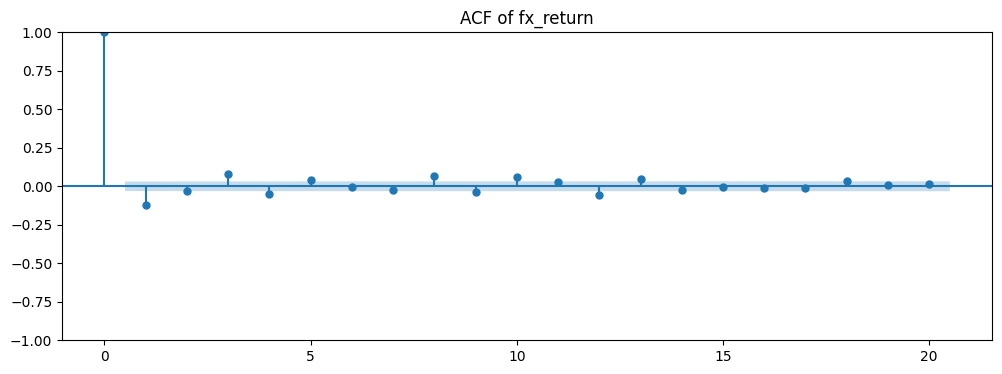

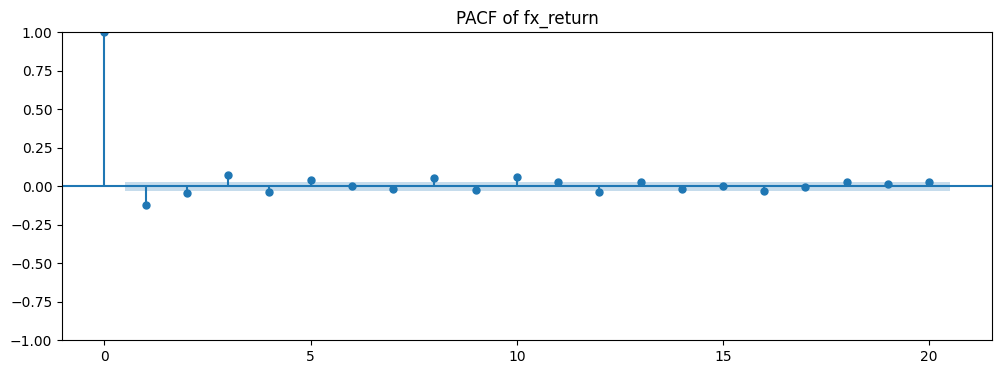

### Ljung–Box test on fx_return

,Lag,lb_stat,lb_pvalue,Conclusion
0,5,109.190694,6.074574e-22,Autocorrelation detected
1,10,147.409511,1.270832e-26,Autocorrelation detected
2,20,181.742976,4.424123e-28,Autocorrelation detected


In [8]:
y = processed_df["fx_return"].dropna()
n = len(y)
max_lag = 20
conf_bound = 1.96 / np.sqrt(n)

acf_vals = acf(y, nlags=max_lag, fft=True)
pacf_vals = pacf(y, nlags=max_lag, method="ywm")
acf_pacf_results = pd.DataFrame({
    "Lag": range(max_lag + 1),
    "ACF": acf_vals,
    "PACF": pacf_vals
})
acf_pacf_results["ACF significant"] = acf_pacf_results["ACF"].abs() > conf_bound
acf_pacf_results["PACF significant"] = acf_pacf_results["PACF"].abs() > conf_bound
acf_pacf_results.loc[acf_pacf_results["Lag"] == 0, ["ACF significant", "PACF significant"]] = False

print(f"95% confidence bound: ±{conf_bound:.4f}")
print("Significant ACF lags:", acf_pacf_results.loc[acf_pacf_results["ACF significant"], "Lag"].tolist())
print("Significant PACF lags:", acf_pacf_results.loc[acf_pacf_results["PACF significant"], "Lag"].tolist())
display(acf_pacf_results)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(y, lags=max_lag, ax=ax)
ax.set_title("ACF of fx_return")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(y, lags=max_lag, ax=ax, method="ywm")
ax.set_title("PACF of fx_return")
plt.show()

lb_lags = [5, 10, 20]
ljung_return = acorr_ljungbox(y, lags=lb_lags, return_df=True)
ljung_return.index.name = "Lag"
ljung_return = ljung_return.reset_index()
ljung_return["Conclusion"] = np.where(ljung_return["lb_pvalue"] < 0.05, "Autocorrelation detected", "No autocorrelation")

display(Markdown("### Ljung–Box test on fx_return"))
display(ljung_return)

acf_pacf_results.to_csv(TABLE_DIR / "acf_pacf_results.csv", index=False)
ljung_return.to_csv(TABLE_DIR / "ljung_box_test.csv", index=False)

## **Volatility clustering tests**

Tests in this section:

1. Ljung-Box on `abs_return`
2. Ljung-Box on `squared_return`
3. ACF of volatility proxy

If the p-values ​​are close to 0, volatility clustering is very clear and the GARCH-family is a suitable choice.

,Variable,Lag,lb_stat,lb_pvalue,Conclusion
0,abs_return,5,1015.330069,2.883296e-217,Volatility clustering detected
1,abs_return,10,1495.364960,0.000000e+00,Volatility clustering detected
2,abs_return,20,1694.245268,0.000000e+00,Volatility clustering detected
3,squared_return,5,49.091634,2.125578e-09,Volatility clustering detected
4,squared_return,10,83.854137,8.779625e-14,Volatility clustering detected
5,squared_return,20,90.619578,5.775237e-11,Volatility clustering detected


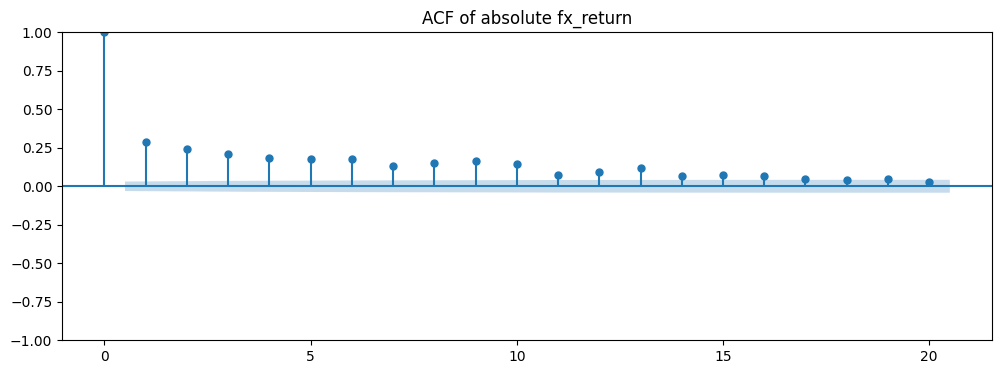

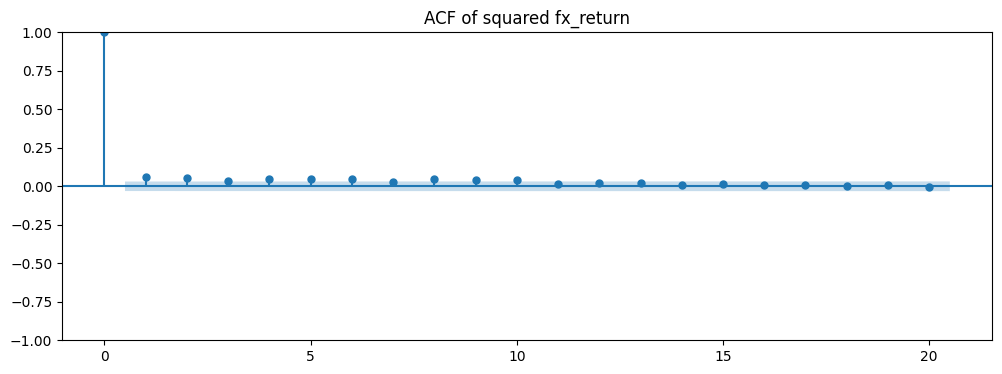

In [9]:
vol_test_data = pd.DataFrame({
    "abs_return": processed_df["fx_return"].abs(),
    "squared_return": processed_df["fx_return"] ** 2
}).dropna()

vol_lb_tables = []
for col in vol_test_data.columns:
    tmp = acorr_ljungbox(vol_test_data[col], lags=lb_lags, return_df=True)
    tmp.index.name = "Lag"
    tmp = tmp.reset_index()
    tmp.insert(0, "Variable", col)
    tmp["Conclusion"] = np.where(tmp["lb_pvalue"] < 0.05, "Volatility clustering detected", "No volatility clustering")
    vol_lb_tables.append(tmp)

vol_ljung = pd.concat(vol_lb_tables, ignore_index=True)
display(vol_ljung)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(vol_test_data["abs_return"], lags=max_lag, ax=ax)
ax.set_title("ACF of absolute fx_return")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(vol_test_data["squared_return"], lags=max_lag, ax=ax)
ax.set_title("ACF of squared fx_return")
plt.show()

vol_ljung.to_csv(TABLE_DIR / "volatility_clustering_test.csv", index=False)

## **ARCH-LM test**

ARCH-LM checks for conditional heteroskedasticity in the raw
USD/VND return series before volatility-model estimation.

- H₀: no ARCH effect
- H₁: ARCH effect exists
- If `p-value < 0.05`: preliminary evidence supports the use
  of GARCH-family models

In [10]:
arch_y = processed_df[TARGET_COL].dropna()

lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
    arch_y,
    nlags=ARCH_LAGS,
)

arch_results = pd.DataFrame([{
    "series": TARGET_COL,
    "n_obs": len(arch_y),
    "arch_lags": ARCH_LAGS,
    "arch_lm_stat": lm_stat,
    "arch_lm_pvalue": lm_pvalue,
    "arch_f_stat": f_stat,
    "arch_f_pvalue": f_pvalue,
    "arch_effects_5pct": lm_pvalue < 0.05,
}])

display(arch_results.round(6))

arch_results.to_csv(TABLE_DIR / "arch_test.csv", index=False)

,series,n_obs,arch_lags,arch_lm_stat,arch_lm_pvalue,arch_f_stat,arch_f_pvalue,arch_effects_5pct
0,fx_return,4020,10,59.51245,0.0,6.024327,0.0,True


## **VIF**

In [11]:
vif_input = processed_df[VIF_COLS].dropna().copy()
vif_design = add_constant(vif_input, has_constant="add")

vif_rows = []

for i, col in enumerate(vif_design.columns):
    if col == "const":
        continue

    vif_rows.append({
        "variable": col,
        "n_obs": len(vif_design),
        "VIF": variance_inflation_factor(
            vif_design.to_numpy(dtype=float),
            i,
        ),
    })

vif_results = (
    pd.DataFrame(vif_rows)
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_results.round(6))

vif_results.to_csv(TABLE_DIR / "vif_results.csv", index=False)

,variable,n_obs,VIF
0,us10y_change,4020,1.117249
1,vix_change,4020,1.101188
2,oil_change,4020,1.071520
3,dxy_return,4020,1.062473
4,vnindex_return,4020,1.006820
5,crisis_dummy,4020,1.001018


In [12]:
shock_corr = processed_df[SHOCK_COLS].corr()
shock_corr.to_csv(TABLE_DIR / "shock_correlation_matrix.csv")

display(shock_corr.round(4))

,vix_change,us10y_change,dxy_return,oil_change,vnindex_return
vix_change,1.0000,-0.2338,0.0857,-0.1853,-0.0769
us10y_change,-0.2338,1.0000,0.1544,0.1559,0.0441
dxy_return,0.0857,0.1544,1.0000,-0.1299,0.0010
oil_change,-0.1853,0.1559,-0.1299,1.0000,0.0117
vnindex_return,-0.0769,0.0441,0.0010,0.0117,1.0000


## **Final testing conclusion**

1. **Statistics:** The return/change variables are I(0), so they can be used directly in the time-series model without further differencing.

2. **Autocorrelation:** Ljung–Box and ACF/PACF show that `fx_return` still has autocorrelation, so the mean equation should have AR/MA or ARMAX terms.

3. **Volatility Clustering:** Absolute/squared returns have strong autocorrelation, indicating volatility clustering.

4. **ARCH Effect:** ARCH-LM rejects H₀ no ARCH effect, so GARCH-family is necessary.

5. **Normality:** Jarque–Bera rejects normality, large skewness/kurtosis, so Student-t or GED should be used instead of Gaussian.

6. **Model direction:** The appropriate specification is ARMAX/AR-EGARCH/GARCH with student-t errors and crisis dummies.

> The diagnostic tests indicate that the transformed return and change variables are stationary. However, the USD/VND return series exhibits significant autocorrelation, strong volatility clustering, ARCH effects, non-normality. These findings justify the use of GARCH-family models, particularly EGARCH or GARCH with Student-t errors and crisis dummy variables.